<a href="https://colab.research.google.com/github/ramvrum/dap-2024/blob/main/les05/rep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №5. Визуализация данных

In [1]:
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

print(f"Python version: {sys.version}")
print(f"Numpy version: {np.version.version}")
print(f"Matplotlib version: {mpl.__version__}")

%matplotlib inline

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Numpy version: 2.0.2
Matplotlib version: 3.10.0


Задача **1**

Постройте два линейных графика функции $y=\frac{2}{x}+3$ на одной оси координат, первый для диапазона x=[-10;0], а второй для x=[0;7].

* Графики должны быть помещены на оси с пределами xlim(-10, 10) и ylim(-10, 10), иметь подписи к осям, легенду и заголовок.
* Первый график должен быть красного цвета и нарисован штрихпунктирной линией
* Второй график должен иметь цвет (1.0,0.2,0.3) и нарисован сплошной линией


/tmp/ipython-input-2767485222.py:4: RuntimeWarning: divide by zero encountered in divide
  y1 = 2 / x1 + 3
/tmp/ipython-input-2767485222.py:5: RuntimeWarning: divide by zero encountered in divide
  y2 = 2 / x2 + 3


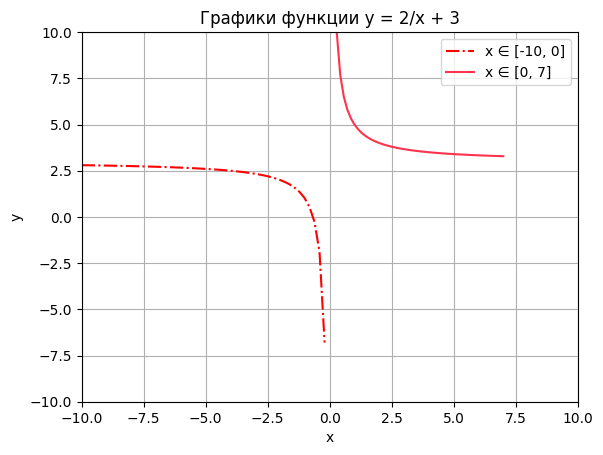

In [6]:
x1 = np.linspace(-10, 0)
x2 = np.linspace(0, 7)

y1 = 2 / x1 + 3
y2 = 2 / x2 + 3

plt.figure()
plt.plot(x1, y1, color='red', linestyle='-.', label='x ∈ [-10, 0]')
plt.plot(x2, y2, color=(1.0, 0.2, 0.3), linestyle='-', label='x ∈ [0, 7]')

plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Графики функции y = 2/x + 3')
plt.legend()
plt.grid(True)
plt.show()

Задача **2**

Постройте диаграмму рассеяния для набора данных titanic (файл ./data/titanic.csv).

* По оси X - возврат пассажира (Age)
* По оси Y - стоимость билета (Fare)
* Для выживших пассажиров используется маркер зеленый круг (Survived)
* Для не выживших пассажиров используется маркер красный крест (Survived)
* График должен подписи к осям и легенду и заголовок

Данные для которых не указан возврат или стоимость билета должны быть исключены

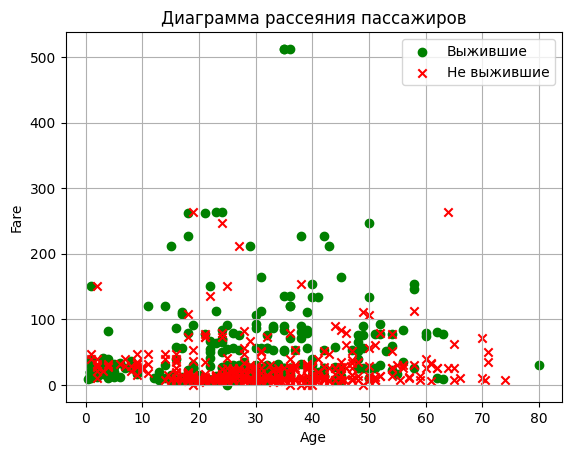

In [26]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/ramvrum/dap-2024/main/les05/data/titanic.csv')
df = df.dropna(subset=['Age', 'Fare'])

plt.figure()

survived = df[df['Survived'] == 1]
plt.scatter(survived['Age'], survived['Fare'], color='green', marker='o', label='Выжившие')

not_survived = df[df['Survived'] == 0]
plt.scatter(not_survived['Age'], not_survived['Fare'], color='red', marker='x', label='Не выжившие')

plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Диаграмма рассеяния пассажиров')
plt.legend()
plt.grid(True)
plt.show()

Задача **3**

Для первоначального анализа данных часто используются диаграммы рассеяния для всех признаков из набора данных. Это позволяет визуально увидеть зависимости между признаками и выбросы.
Для набора данных [iris](https://ru.wikipedia.org/wiki/%D0%98%D1%80%D0%B8%D1%81%D1%8B_%D0%A4%D0%B8%D1%88%D0%B5%D1%80%D0%B0) постройте на одном холсте 16 диаграмм рассеяния показывающих зависимости между всеми признаками набора ('sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)')

* Холст должен содержать 16 графиков на отдельных осях (см. иллюстрацию к статье в Википедия)
* Цвет маркеров должен зависеть от вида ирисов (iris.target)
* Графики должны иметь подписи к осям, легенду и общий заголовок

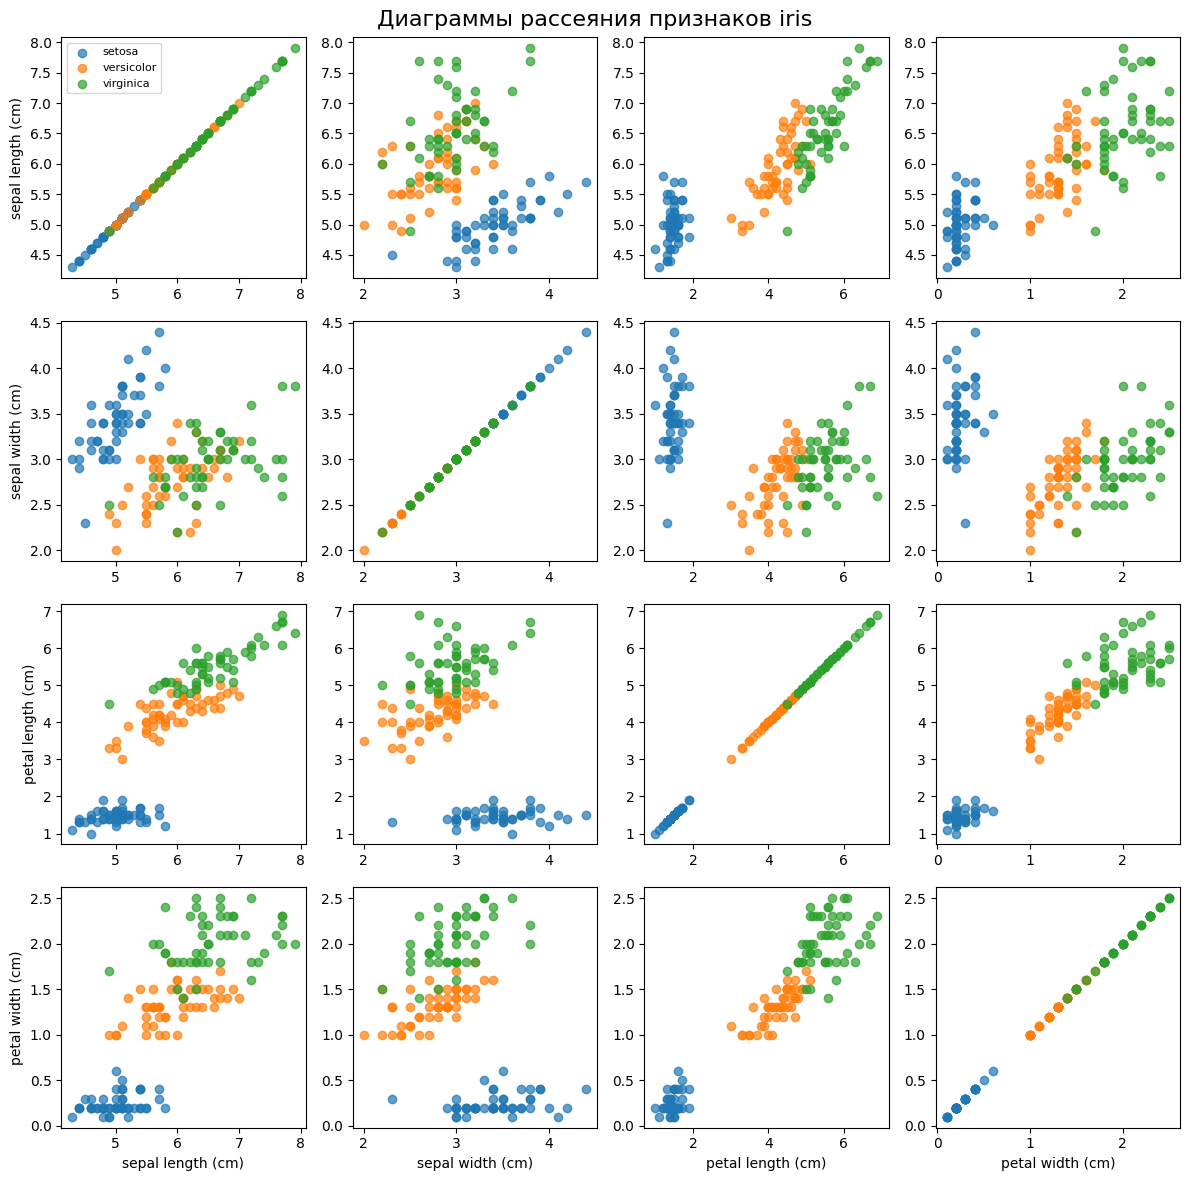

In [19]:
from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Диаграммы рассеяния признаков iris', fontsize=16)

colors = ['red', 'green', 'blue']

for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        for target, color in zip(range(3), colors):
            ax.scatter(X[y == target, j], X[y == target, i], label=target_names[target], alpha=0.7)
        if i == 3:
            ax.set_xlabel(feature_names[j])
        if j == 0:
            ax.set_ylabel(feature_names[i])
        if i == 0 and j == 0:
            ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

Задача **4**

Постройте на одном холсте и разный осях следующие распределения для набора данных titanic (./data/titanic.csv):

* Постройте гистограмму распределения пассажиров по возрасту (Age). Интервал 5 лет.
* Постройте гистограмму распределения пассажиров женского пола по стоимости билетов (Fare). Подберите удобный интервал
* График должен иметь подписи к осям, легенду и заголовок

Данные для которых не указан возраст или стоимость билета должны быть исключены

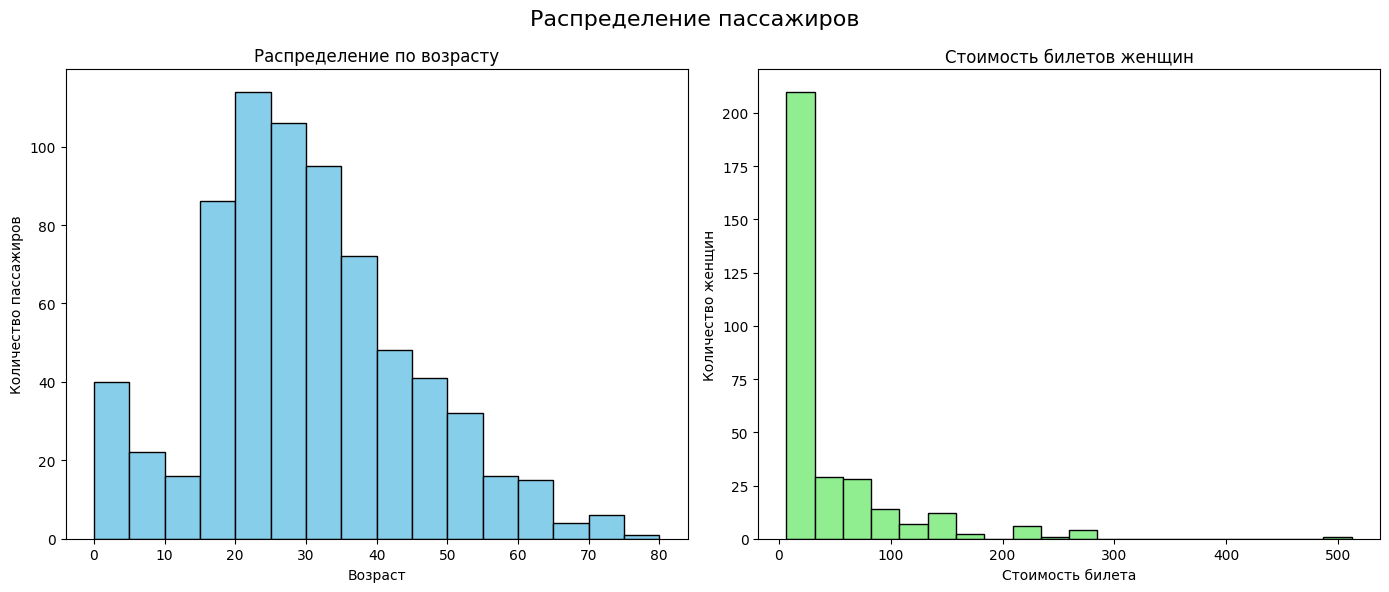

In [25]:
data = pd.read_csv(
    "https://raw.githubusercontent.com/ramvrum/dap-2024/main/les05/data/titanic.csv"
)

data_age = data[data["Age"].notna()]
data_fare_female = data[(data["Sex"] == "female") & (data["Fare"].notna())]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Распределение пассажиров", fontsize=16)

axes[0].hist(data_age["Age"], bins=range(0, 85, 5), color="skyblue", edgecolor="black")
axes[0].set_xlabel("Возраст")
axes[0].set_ylabel("Количество пассажиров")
axes[0].set_title("Распределение по возрасту")

axes[1].hist(data_fare_female["Fare"], bins=20, color="lightgreen", edgecolor="black")
axes[1].set_xlabel("Стоимость билета")
axes[1].set_ylabel("Количество женщин")
axes[1].set_title("Стоимость билетов женщин")

plt.tight_layout()
plt.show()

Задача **5**

Для набора данных для набора данных titanic (./data/titanic.csv) постройте следующую столбчатую диаграмму:

* Диаграмма должна быть вертикальной
* По оси X - класс каюты пассажира (Pclass)
* По оси Y - средняя стоимость за проезд для данного класса (Fare)
* График должен иметь подписи к осям, легенду и заголовок

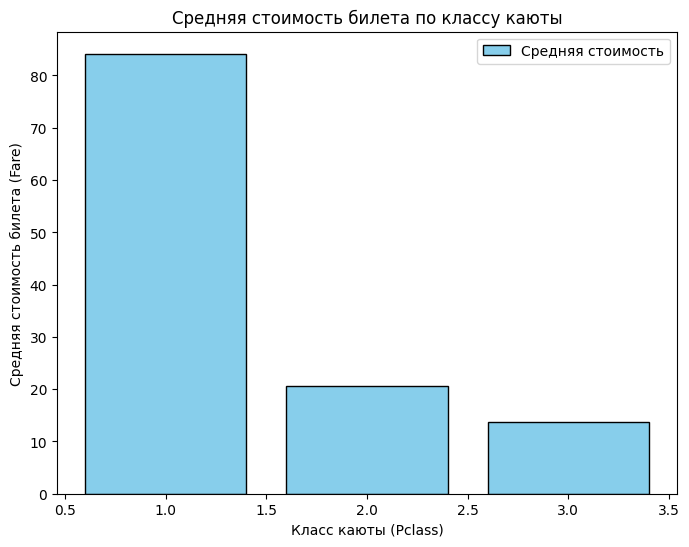

In [24]:

data = pd.read_csv(
    "https://raw.githubusercontent.com/ramvrum/dap-2024/main/les05/data/titanic.csv"
)

data_clean = data[data["Fare"].notna()]

avg_fare = data_clean.groupby("Pclass")["Fare"].mean()

plt.figure(figsize=(8, 6))
bars = plt.bar(
    avg_fare.index,
    avg_fare.values,
    color="skyblue",
    edgecolor="black",
    label="Средняя стоимость",
)

plt.xlabel("Класс каюты (Pclass)")
plt.ylabel("Средняя стоимость билета (Fare)")
plt.title("Средняя стоимость билета по классу каюты")
plt.legend()

plt.show()


Задача **6**

Для набора данных для набора данных titanic (./data/titanic.csv) постройте следующую столбчатую диаграмму c накоплением:

* Диаграмма должна быть вертикальной
* По оси X - класс каюты пассажира (Pclass)
* По оси Y - количество пассажиров с разбивкой по полу (Sex)
* График должен иметь подписи к осям, легенду и заголовок

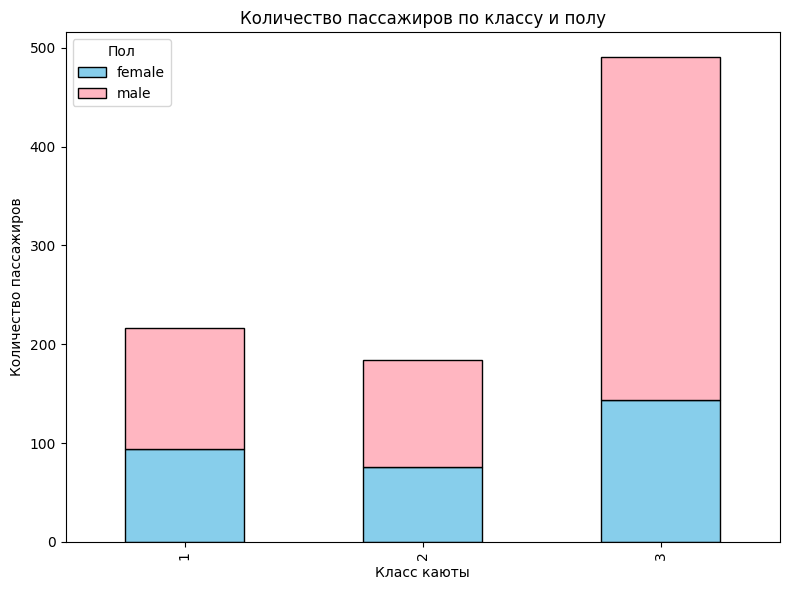

In [27]:
data = pd.read_csv(
    "https://raw.githubusercontent.com/ramvrum/dap-2024/main/les05/data/titanic.csv"
)

data_clean = data[data["Pclass"].notna() & data["Sex"].notna()]

counts = data_clean.groupby(["Pclass", "Sex"]).size().unstack()

counts.plot(
    kind="bar",
    stacked=True,
    color=["skyblue", "lightpink"],
    edgecolor="black",
    figsize=(8, 6),
)

plt.xlabel("Класс каюты")
plt.ylabel("Количество пассажиров")
plt.title("Количество пассажиров по классу и полу")
plt.legend(title="Пол")

plt.tight_layout()
plt.show()

Задача **7**

Для набора данных iris постройте круговую диаграмму

* Диаграмма должна иметь 3 сектора отражающих долю ирисов данного вида в наборе
* Сектор с максимальной долей долен быть выдвинут
* График должен иметь подписи к осям, легенду и заголовок

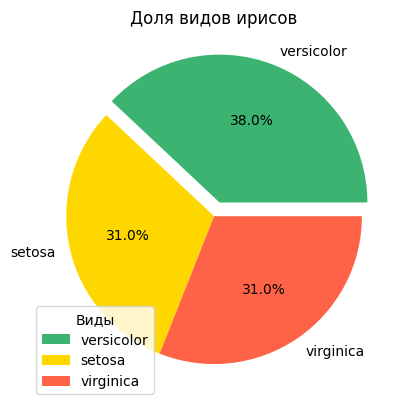

In [37]:
from sklearn.datasets import load_iris
iris = load_iris()

target_series = pd.Series(iris.target)

freq_table = target_series.sample(100).value_counts()

plt.pie(
    freq_table,
    labels=[iris.target_names[i] for i in freq_table.index],
    colors=["mediumseagreen", "gold", "tomato"],
    autopct="%.1f%%",
    explode=[0.1, 0, 0]
)
plt.title("Доля видов ирисов")
plt.legend(title='Виды')
plt.show()


Задача **8**

Использую библиотеку [Seaborn](https://seaborn.pydata.org/) постройте гистограмму для возраста пассажиров "Титаника"

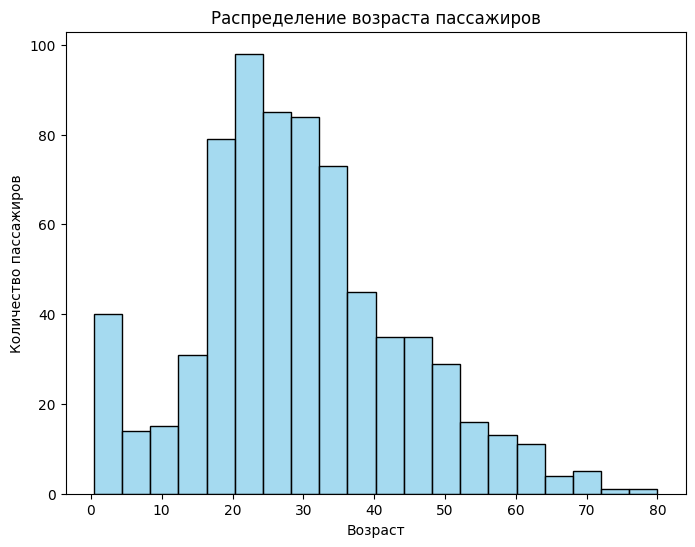

In [39]:
import seaborn as sns

data = pd.read_csv(
    "https://raw.githubusercontent.com/ramvrum/dap-2024/main/les05/data/titanic.csv"
)

data_age = data[data['Age'].notna()]

plt.figure(figsize=(8,6))
sns.histplot(data_age['Age'], bins=20, kde=False, color='skyblue', edgecolor='black')
plt.xlabel('Возраст')
plt.ylabel('Количество пассажиров')
plt.title('Распределение возраста пассажиров')
plt.show()

## Вопросы


1. Для чего используется диаграмма рассеяния?

Диаграмма рассеяния используется для визуализации зависимости между несколькими количественными переменными, выявления трендов, кластеров и выбросов.

2. Что такое гистограмма, чем она отличается от столбчатой диаграммы?

Гистограмма показывает, сколько раз встречаются числа в разных диапазонах, а столбчатая диаграмма показывает значения для разных категорий. Главное отличие — гистограмма для чисел, столбчатая диаграмма для категорий.

3. Как задать цвет линии в линейном графике Matplotlib?

Цвет линии в Matplotlib задаётся параметром color в plt.plot().

4. Чем класс plt.Figure отличается от объекта  plt.Axes?

plt.Figure — это весь холст, plt.Axes — отдельный график (оси) внутри Figure.

5. Matplotlib не позволяет управлять типом маркера scatter графика. Да или нет?

Нет, тип маркера scatter-графика можно задавать через параметр marker.

6. Matplotlib единственная библиотека для построения графиков в Python. Да или нет?

Нет, кроме Matplotlib есть Seaborn, Plotly, Bokeh и другие библиотеки.

7. Matplotlib не позволяет сохранить график в виде файла, нужно делать скриншот?

Нет, Matplotlib позволяет сохранять график напрямую через plt.savefig().

8. В наборе данных iris представлены 4 вида ирисов. Да или нет?

Нет, в наборе данных iris представлены 3 вида ирисов.

9. Для всех пассажиров "Титаника" указан возраст. Да или нет?

Нет.

10. Как на одном холсте может располагаться не более 16 диаграмм, это обусловлено тем что размер диаграммы нельзя изменить и более мелкие графики попросту не будут видны.

Нет, на одном холсте может быть больше 16 диаграмм, просто при большом количестве графиков отдельные диаграммы становятся маленькими и плохо читаемыми.